# STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
# import transformers
# print(transformers.__version__)
# print(torch.__version__)
# print(torch.version.cuda)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# STEP 2 — Load Dataset (final_combined.csv)

In [2]:
df = pd.read_csv("../../datasets/processed/final_combined.csv")

# Keep only subject + label
df_subject = df[["subject", "label"]].dropna()
df_subject["subject"] = df_subject["subject"].astype(str)

print(df_subject.head())
print("Total samples:", len(df_subject))

                                      subject  label
0  URGENT BUSINESS ASSISTANCE AND PARTNERSHIP      1
1         URGENT ASSISTANCE /RELATIONSHIP (P)      1
2                             GOOD DAY TO YOU      1
3                             GOOD DAY TO YOU      1
4                     I Need Your Assistance.      1
Total samples: 180441


/tmp/ipykernel_62346/3736549266.py:1: DtypeWarning: Columns (3,4,5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../datasets/processed/final_combined.csv")


# STEP 3 — Train/Validation Split

In [3]:
train_df, val_df = train_test_split(
    df_subject,
    test_size=0.1,
    stratify=df_subject["label"],
    random_state=42
)

print(len(train_df), len(val_df))


162396 18045


# STEP 4 — Build Tokenizer

In [ ]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Assigned pad_token =", tokenizer.pad_token)

# Check the padding token
print(f"Padding token: {tokenizer.pad_token}")

# Check the ID of the padding token
print(f"Padding token ID: {tokenizer.pad_token_id}")

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Padding token: [PAD]
Padding token ID: 0


# STEP 5 — HuggingFace Dataset Format

In [5]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)

def tokenize(batch):
    return tokenizer(
        batch["subject"],
        truncation=True,
        max_length=128  # subject lines are short, but try with 64/128/256 later
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["subject", "__index_level_0__"])
val_ds   = val_ds.remove_columns(["subject", "__index_level_0__"])


Map: 100%|██████████| 18045/18045 [00:00<00:00, 48892.84 examples/s]


# STEP 6 — Load Model (DeBERTa-v3-base)

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# Enable gradient checkpointing
# model.gradient_checkpointing_enable()


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# STEP 7 — Metrics (Accuracy, Precision, Recall, F1)

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    cm = confusion_matrix(labels, preds)

    print("Confusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# STEP 8 — Training Arguments

In [8]:
training_args = TrainingArguments(
    output_dir="subject_model_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    
    num_train_epochs=5,
    weight_decay=0.01,
    
    fp16=True,
    bf16=False,
    max_grad_norm=1.0,
    
    optim="adamw_torch",
    label_smoothing_factor=0.1,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

# STEP 9 — Data Collator

In [9]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# STEP 10 — Trainer

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


/tmp/ipykernel_62346/818128648.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# STEP 11 — Train

In [11]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.277900,0.276464,0.963203,0.959504,0.967360,0.963416
2,0.244000,0.255720,0.971737,0.969190,0.974552,0.971864
3,0.235600,0.249454,0.974009,0.973687,0.974441,0.974064
4,0.225600,0.247452,0.976559,0.976968,0.976212,0.976590
5,0.218500,0.248528,0.976669,0.974975,0.978535,0.976752


Confusion Matrix:
[[8638  369]
 [ 295 8743]]
Confusion Matrix:
[[8727  280]
 [ 230 8808]]
Confusion Matrix:
[[8769  238]
 [ 231 8807]]
Confusion Matrix:
[[8799  208]
 [ 215 8823]]
Confusion Matrix:
[[8780  227]
 [ 194 8844]]


TrainOutput(global_step=50750, training_loss=0.25203152839773396, metrics={'train_runtime': 14493.5764, 'train_samples_per_second': 56.023, 'train_steps_per_second': 3.502, 'total_flos': 1.0935617796993024e+16, 'train_loss': 0.25203152839773396, 'epoch': 5.0})

# STEP 12 — Confusion Matrix

===== VALIDATION METRICS =====


Confusion Matrix:
[[8780  227]
 [ 194 8844]]
eval_loss: 0.24852831661701202
eval_accuracy: 0.9766694375173178
eval_precision: 0.974975195678536
eval_recall: 0.978535074131445
eval_f1: 0.9767518913247556
eval_runtime: 71.0389
eval_samples_per_second: 254.016
eval_steps_per_second: 31.757
epoch: 5.0
Confusion Matrix:
[[8780  227]
 [ 194 8844]]


<Figure size 600x600 with 0 Axes>

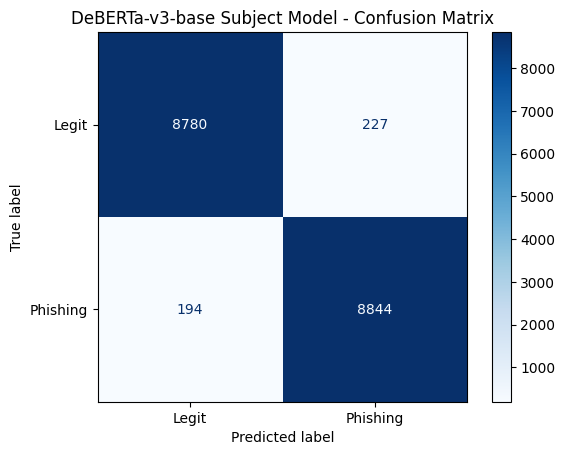

In [12]:
print("===== VALIDATION METRICS =====")
metrics = trainer.evaluate()

for key, value in metrics.items():
    print(f"{key}: {str(value)}")

# Visualize confusion matrix
predictions = trainer.predict(val_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("DeBERTa-v3-base Subject Model - Confusion Matrix")
plt.show()


# STEP 13 — Save Model + Tokenizer

In [13]:
trainer.save_model("subject_encoder") 
tokenizer.save_pretrained("subject_encoder_tokenizer")

('subject_encoder_tokenizer/tokenizer_config.json',
 'subject_encoder_tokenizer/special_tokens_map.json',
 'subject_encoder_tokenizer/spm.model',
 'subject_encoder_tokenizer/added_tokens.json',
 'subject_encoder_tokenizer/tokenizer.json')

# STEP 14 — Test model with a single user input (Subject text)

In [18]:
def predict_subject(text):
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    )

    encoded = {k: v.to(model.device) for k, v in encoded.items()}
    with torch.no_grad():
        output = model(**encoded)
        pred = torch.argmax(output.logits, dim=1).item()
    
    return {
        "prediction": "🔴 PHISHING" if pred == 1 else "🟢 LEGITIMATE",
        "input": text 
    }


# Try any example:
while True:
    """Please confirm your banking details to avoid suspension."""
    text = input("Enter an email subject: ")
    if text.lower() == "b" or text.lower() == "break":
        break 
    for key, value in predict_subject(text).items():
        print(f"{key}: {value}")

prediction: 🟢 LEGITIMATE
input: AtCoder Beginner Contest 435 Announcement
prediction: 🟢 LEGITIMATE
input: Defalt, I'm your fan on GitHub
